In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [7]:
transform = transforms.ToTensor()

In [8]:
train_dataset = torchvision.datasets.MNIST(
    root = './data',
    train = True,
    transform = transform,
    download = True
)

test_dataset = torchvision.datasets.MNIST(
    root = './data',
    train = False,
    transform = transform,
    download = True
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 138MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 12.1MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 28.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.08MB/s]


In [9]:
train_loader = torch.utils.data.DataLoader(train_dataset,batch_size = 64,shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size = 64,shuffle = True)


In [21]:
class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN,self).__init__()

    self.conv1 = nn.Conv2d(
      in_channels = 1,
      out_channels = 8,
      kernel_size = 3,
      stride = 1,
      padding = 1
  )
    self.pool = nn.MaxPool2d(kernel_size = 2,stride = 2)
    self.fc1 = nn.Linear(8*14*14,10)

  def forward(self,x):
      x = self.conv1(x)
      x = torch.relu(x)

      x = self.pool(x)
      x = x.view(x.size(0),-1)

      out = self.fc1(x)
      return x




model = SimpleCNN()
optimizer = optim.Adam(model.parameters(),lr = 0.001)
criterion = nn.CrossEntropyLoss()



In [23]:
for epoch in range(3):
  for images,labels in train_loader:
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs,labels)

    loss.backward()
    optimizer.step()
  print(f"epoch {epoch+1} completed")



epoch 1 completed
epoch 2 completed
epoch 3 completed


In [27]:
correct = 0
total= 0

with torch.no_grad():
  for images,labels in test_loader:
    outputs = model(images)
    _,predicted = torch.max(outputs,1)
    total += labels.size(0)
    correct +=(predicted == labels).sum().item()

print(f"accracy:",100*correct/total)

accracy: 9.8


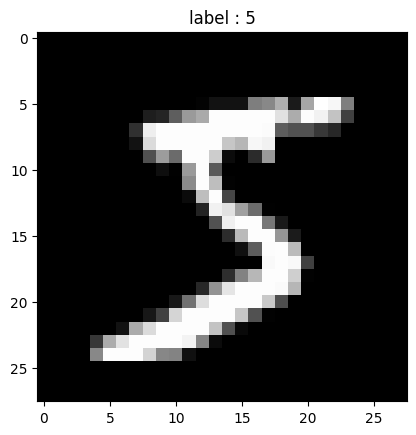

In [29]:
image,label  = train_dataset[0]

plt.imshow(image.squeeze(),cmap = 'gray')
plt.title(f"label : {label}")
plt.show()

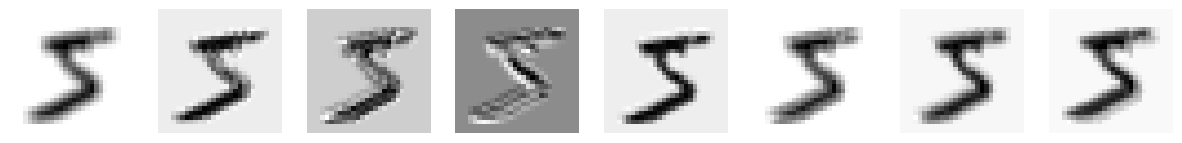

In [30]:
with torch.no_grad():
  image = image.unsqueeze(0)
  feature_maps = model.conv1(image)


fig,ax = plt.subplots(1,8,figsize = (15,5))

for i in range(8):
  ax[i].imshow(feature_maps[0][i],cmap = 'gray')
  ax[i].axis('off')


plt.show()

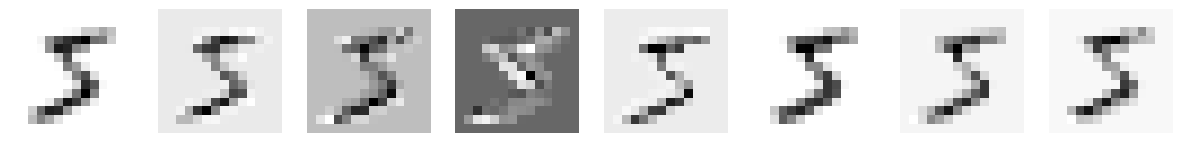

In [34]:
pooled = model.pool(feature_maps)
fig,ax = plt.subplots(1,8,figsize = (15,5))

for i in range(8):
  ax[i].imshow(pooled[0][i],cmap = 'gray')
  ax[i].axis('off')

plt.show()

In [32]:
pooled

tensor([[[[ 2.7077,  2.7077,  2.7077,  ...,  2.7077,  2.7077,  2.7077],
          [ 2.7077,  2.7077,  2.7077,  ...,  2.7077,  2.7077,  2.7077],
          [ 2.7077,  2.7077,  2.7077,  ...,  0.7100,  2.7077,  2.7077],
          ...,
          [ 2.7077,  2.7077,  1.1643,  ...,  2.7077,  2.7077,  2.7077],
          [ 2.7077,  2.7077,  0.5167,  ...,  2.7077,  2.7077,  2.7077],
          [ 2.7077,  2.7077,  2.7077,  ...,  2.7077,  2.7077,  2.7077]],

         [[-0.0675, -0.0675, -0.0675,  ..., -0.0675, -0.0675, -0.0675],
          [-0.0675, -0.0675, -0.0675,  ..., -0.0675, -0.0675, -0.0675],
          [-0.0675, -0.0675, -0.0675,  ..., -0.0548, -0.0675, -0.0675],
          ...,
          [-0.0675, -0.0675, -0.0509,  ..., -0.0675, -0.0675, -0.0675],
          [-0.0675, -0.0675, -0.1552,  ..., -0.0675, -0.0675, -0.0675],
          [-0.0675, -0.0675, -0.0675,  ..., -0.0675, -0.0675, -0.0675]],

         [[-0.3302, -0.3302, -0.3302,  ..., -0.3302, -0.3302, -0.3302],
          [-0.3302, -0.3302, -